# 과제 - 신경망을 이용한 손글씨 숫자 인식



## 1. 환경설정



In [3]:
# Colab: 이 셀을 가장 먼저 실행하세요 (저장소 클론 후 경로·모듈 로드)
# 주의: Colab에서는 GitHub 저장소 URL과 Personal Access Token을 반드시 입력해야 합니다.
import os
import sys
from pathlib import Path

if "google.colab" in sys.modules:
    from getpass import getpass

    git_url = input("GitHub 저장소 URL (예: github.com/USERNAME/mnist-lab.git): ").strip()
    token = getpass("GitHub Personal Access Token (private 저장소인 경우): ")

    # URL 마지막 경로를 저장소 폴더명으로 사용합니다. (예: .../mnist-lab.git -> mnist-lab)
    repo_name = Path(git_url.rstrip("/")).name
    if repo_name.endswith(".git"):
        repo_name = repo_name[:-4]

    !git clone https://{token}@{git_url}
    os.chdir(repo_name)
    sys.path.insert(0, str(Path.cwd() / "src"))
else:
    sys.path.insert(0, "./src")


## 2. 데이터 로드

In [1]:
import sys

sys.modules.pop("data", None)
sys.path.insert(0, r"C:\github\jungle\ai\mnist-lab\src")

In [2]:
import os, sys
print(os.getcwd())
print(sys.path[:5])

import data
print(data)
print(getattr(data, "__file__", "no file"))

C:\github\jungle\ai\mnist-lab
['C:\\github\\jungle\\ai\\mnist-lab\\src', 'C:\\github\\jungle\\ai\\mnist-lab', 'C:\\Users\\user\\anaconda3\\python312.zip', 'C:\\Users\\user\\anaconda3\\DLLs', 'C:\\Users\\user\\anaconda3\\Lib']
<module 'data' from 'C:\\github\\jungle\\ai\\mnist-lab\\src\\data.py'>
C:\github\jungle\ai\mnist-lab\src\data.py


In [3]:
from data import load_mnist

(x_train, y_train), (x_test, y_test) = load_mnist()
print('Train:', x_train.shape, y_train.shape)
print('Test:', x_test.shape, y_test.shape)

Train: (60000, 784) (60000,)
Test: (10000, 784) (10000,)


## 3. 구현 및 테스트 통과 확인

`src/` 아래 역할별 파일의 **TODO**를 순서대로 구현한 뒤 아래 셀을 실행하세요.
- 주요 구현 파일: `activations.py`, `layers.py`, `losses.py`, `optimizers.py`, `network.py`, `training.py`
- 구현 파일은 역할별 모듈을 직접 import합니다. 예: `from network import NeuralNetwork`
- 개발 순서: 과제 안내문 참조
- 테스트: `tests/` 아래의 단계별 단위 테스트를 필요한 파일부터 실행합니다. 처음에는 전체 테스트보다 맡은 부분의 테스트 파일을 먼저 실행하세요.
    - ReLU만 확인: `TEST_TARGET = "tests/test_relu.py"`
    - 파일 안의 일부 테스트만 확인: `PYTEST_KEYWORD = "backward"`
    - 전체 테스트 확인: `TEST_TARGET = "tests/"`

In [4]:
import subprocess
import sys
from pathlib import Path

# Colab/로컬 모두 현재 노트북 실행 위치를 저장소 루트로 사용합니다.
repo_dir = Path.cwd()

# 처음에는 자신이 구현 중인 부분의 테스트 파일만 실행하세요.
# 예: tests/test_relu.py, tests/test_affine.py, tests/test_training.py
TEST_TARGET = "tests/"

# 특정 이름이 들어간 테스트만 실행하고 싶을 때 사용합니다.
# 예: "backward". 전체 파일을 실행하려면 빈 문자열로 둡니다.
PYTEST_KEYWORD = ""

cmd = [sys.executable, "-m", "pytest", TEST_TARGET, "-v"]
if PYTEST_KEYWORD:
    cmd.extend(["-k", PYTEST_KEYWORD])

print("실행 경로:", repo_dir)
print("실행 명령:", " ".join(cmd))
result = subprocess.run(
    cmd,
    capture_output=True,
    text=True,
    cwd=str(repo_dir)
)
print(result.stdout)
if result.stderr:
    print(result.stderr)
if result.returncode == 0:
    print("\n선택한 테스트를 통과했습니다.")
else:
    print("\n선택한 테스트 중 실패가 있습니다.")


실행 경로: C:\github\jungle\ai\mnist-lab
실행 명령: C:\Users\user\anaconda3\python.exe -m pytest tests/ -v
============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-8.4.2, pluggy-1.6.0 -- C:\Users\user\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\github\jungle\ai\mnist-lab
plugins: anyio-4.9.0, langsmith-0.3.45
collecting ... collected 21 items

tests/test_adam.py::TestAdam::test_adam_update_changes_params PASSED     [  4%]
tests/test_affine.py::TestAffine::test_affine_forward_shape PASSED       [  9%]
tests/test_affine.py::TestAffine::test_affine_backward_grad_shape PASSED [ 14%]
tests/test_batchnorm.py::TestBatchNorm::test_batchnorm_forward_shape PASSED [ 19%]
tests/test_batchnorm.py::TestBatchNorm::test_batchnorm_backward_shape PASSED [ 23%]
tests/test_cross_entropy_loss.py::TestCrossEntropyLoss::test_cross_entropy_loss_scalar PASSED [ 28%]
tests/test_cross_entropy_loss.py::TestCrossEntropyLoss::test_cross_entropy_los

## 4. 모델·옵티마이저 생성 및 학습

In [5]:
from network import NeuralNetwork
from optimizers import Adam
from training import train

model = NeuralNetwork(use_batchnorm=True, use_dropout=True)  # BatchNorm, Dropout 필수
optimizer = Adam(lr=0.001)

loss_history = train(model, optimizer, x_train, y_train, epochs=40, batch_size=128)

Epoch 1/40  loss: 0.2491
Epoch 2/40  loss: 0.1056
Epoch 3/40  loss: 0.0778
Epoch 4/40  loss: 0.0601
Epoch 5/40  loss: 0.0494
Epoch 6/40  loss: 0.0417
Epoch 7/40  loss: 0.0359
Epoch 8/40  loss: 0.0333
Epoch 9/40  loss: 0.0285
Epoch 10/40  loss: 0.0251
Epoch 11/40  loss: 0.0238
Epoch 12/40  loss: 0.0220
Epoch 13/40  loss: 0.0208
Epoch 14/40  loss: 0.0184
Epoch 15/40  loss: 0.0181
Epoch 16/40  loss: 0.0158
Epoch 17/40  loss: 0.0159
Epoch 18/40  loss: 0.0163
Epoch 19/40  loss: 0.0145
Epoch 20/40  loss: 0.0123
Epoch 21/40  loss: 0.0136
Epoch 22/40  loss: 0.0118
Epoch 23/40  loss: 0.0119
Epoch 24/40  loss: 0.0108
Epoch 25/40  loss: 0.0129
Epoch 26/40  loss: 0.0100
Epoch 27/40  loss: 0.0109
Epoch 28/40  loss: 0.0098
Epoch 29/40  loss: 0.0103
Epoch 30/40  loss: 0.0095
Epoch 31/40  loss: 0.0085
Epoch 32/40  loss: 0.0076
Epoch 33/40  loss: 0.0080
Epoch 34/40  loss: 0.0082
Epoch 35/40  loss: 0.0081
Epoch 36/40  loss: 0.0084
Epoch 37/40  loss: 0.0074
Epoch 38/40  loss: 0.0073
Epoch 39/40  loss: 0.

## 5. 평가 및 손실 커브

Test Accuracy: 98.54%
Total Params: 537,354


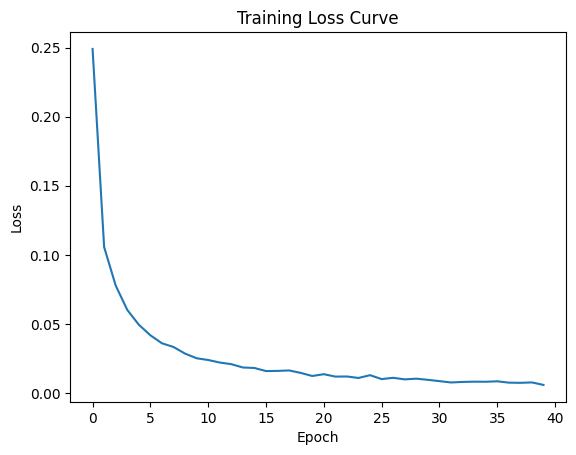

In [6]:
from training import evaluate, plot_loss_history

acc, n_params = evaluate(model, x_test, y_test)
print(f'Test Accuracy: {acc:.2f}%')
print(f'Total Params: {n_params:,}')

plot_loss_history(loss_history)

## 4. 모델·옵티마이저 생성 및 학습

In [7]:
from network import NeuralNetwork
from optimizers import Adam, SGD
from training import train
import time
from losses import cross_entropy_loss
from training import evaluate

def run_train(name, model, optimizer, epochs, batch_size):
    start = time.time()
    loss_history = train(model, optimizer, x_train, y_train, epochs=epochs, batch_size=batch_size)
    sec = time.time() - start

    y_test_pred = model.predict(x_test)
    test_loss = cross_entropy_loss(y_test_pred, y_test)
    test_acc, n_params = evaluate(model, x_test, y_test)

    print(
        f"{name} | epochs={epochs} | batch={batch_size} | "
        f"time={sec:.2f}s | train_loss={loss_history[-1]:.4f} | "
        f"test_loss={test_loss:.4f} | test_acc={test_acc:.2f}% | "
        f"params={n_params:,}"
    )

    return loss_history, sec


# ============================================================
# 1. Batch Size 비교
# lr, optimizer, epoch는 같게 두고 batch_size만 변경
# ============================================================

model_batch_10 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_10 = Adam(lr=0.001)
loss_batch_10, time_batch_10 = run_train("batch_10", model_batch_10, optimizer_batch_10, epochs=20, batch_size=10)

model_batch_128 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_128 = Adam(lr=0.001)
loss_batch_128, time_batch_128 = run_train("batch_128", model_batch_128, optimizer_batch_128, epochs=20, batch_size=128)

model_batch_60000 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_60000 = Adam(lr=0.001)
loss_batch_60000, time_batch_60000 = run_train("batch_60000", model_batch_60000, optimizer_batch_60000, epochs=20, batch_size=60000)


# ============================================================
# 2. Learning Rate 비교
# batch_size, optimizer, epoch는 같게 두고 lr만 변경
# lr=100, lr=0.1은 너무 큰 학습률이 어떤 문제를 만드는지 보기 위한 실험
# ============================================================

model_lr_100 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_100 = Adam(lr=100)
loss_lr_100, time_lr_100 = run_train("lr_100", model_lr_100, optimizer_lr_100, epochs=20, batch_size=128)

model_lr_0_1 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_1 = Adam(lr=0.1)
loss_lr_0_1, time_lr_0_1 = run_train("lr_0.1", model_lr_0_1, optimizer_lr_0_1, epochs=20, batch_size=128)

model_lr_0_001 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_001 = Adam(lr=0.001)
loss_lr_0_001, time_lr_0_001 = run_train("lr_0.001", model_lr_0_001, optimizer_lr_0_001, epochs=20, batch_size=128)

model_lr_0_00001 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_00001 = Adam(lr=0.00001)
loss_lr_0_00001, time_lr_0_00001 = run_train("lr_0.00001", model_lr_0_00001, optimizer_lr_0_00001, epochs=20, batch_size=128)


# ============================================================
# 3. Dropout 비교
# lr, batch_size, optimizer는 같게 두고 dropout 사용 여부만 변경
# ============================================================

model_dropout_on = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_dropout_on = Adam(lr=0.001)
loss_dropout_on, time_dropout_on = run_train("dropout_on", model_dropout_on, optimizer_dropout_on, epochs=100, batch_size=128)

model_dropout_off = NeuralNetwork(use_batchnorm=True, use_dropout=False)
optimizer_dropout_off = Adam(lr=0.001)
loss_dropout_off, time_dropout_off = run_train("dropout_off", model_dropout_off, optimizer_dropout_off, epochs=100, batch_size=128)


# ============================================================
# 4. Optimizer 비교
# lr, batch_size, epoch는 같게 두고 Adam과 SGD 비교
# ============================================================

model_optimizer_adam = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_adam = Adam(lr=0.001)
loss_optimizer_adam, time_optimizer_adam = run_train("optimizer_adam", model_optimizer_adam, optimizer_adam, epochs=20, batch_size=128)

model_optimizer_sgd = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_sgd = SGD(lr=0.001)
loss_optimizer_sgd, time_optimizer_sgd = run_train("optimizer_sgd", model_optimizer_sgd, optimizer_sgd, epochs=20, batch_size=128)


# ============================================================
# 5. BatchNorm 비교
# lr, batch_size, optimizer는 같게 두고 batchnorm 사용 여부만 변경
# ============================================================

model_batchnorm_on = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batchnorm_on = Adam(lr=0.001)
loss_batchnorm_on, time_batchnorm_on = run_train("batchnorm_on", model_batchnorm_on, optimizer_batchnorm_on, epochs=20, batch_size=128)

model_batchnorm_off = NeuralNetwork(use_batchnorm=False, use_dropout=True)
optimizer_batchnorm_off = Adam(lr=0.001)
loss_batchnorm_off, time_batchnorm_off = run_train("batchnorm_off", model_batchnorm_off, optimizer_batchnorm_off, epochs=20, batch_size=128)

Epoch 1/20  loss: 0.3401
Epoch 2/20  loss: 0.2098
Epoch 3/20  loss: 0.1713
Epoch 4/20  loss: 0.1488
Epoch 5/20  loss: 0.1303
Epoch 6/20  loss: 0.1235
Epoch 7/20  loss: 0.1147
Epoch 8/20  loss: 0.1090
Epoch 9/20  loss: 0.1046
Epoch 10/20  loss: 0.0972
Epoch 11/20  loss: 0.0901
Epoch 12/20  loss: 0.0886
Epoch 13/20  loss: 0.0834
Epoch 14/20  loss: 0.0822
Epoch 15/20  loss: 0.0775
Epoch 16/20  loss: 0.0783
Epoch 17/20  loss: 0.0711
Epoch 18/20  loss: 0.0699
Epoch 19/20  loss: 0.0707
Epoch 20/20  loss: 0.0653
batch_10 | epochs=20 | batch=10 | time=1790.33s | train_loss=0.0653 | test_loss=0.0490 | test_acc=98.49% | params=537,354
Epoch 1/20  loss: 0.2446
Epoch 2/20  loss: 0.1057
Epoch 3/20  loss: 0.0762
Epoch 4/20  loss: 0.0616
Epoch 5/20  loss: 0.0488
Epoch 6/20  loss: 0.0413
Epoch 7/20  loss: 0.0357
Epoch 8/20  loss: 0.0316
Epoch 9/20  loss: 0.0283
Epoch 10/20  loss: 0.0257
Epoch 11/20  loss: 0.0222
Epoch 12/20  loss: 0.0238
Epoch 13/20  loss: 0.0196
Epoch 14/20  loss: 0.0181
Epoch 15/20 

## 5. 평가 및 손실 커브


######################################################################
Batch Size Compare
######################################################################
Model       : batch_10
Train Loss  : 0.0653
Test Loss   : 0.0490
Accuracy    : 98.49%
Total Params: 537,354
Time        : 1790.33s
Model       : batch_128
Train Loss  : 0.0135
Test Loss   : 0.0607
Accuracy    : 98.38%
Total Params: 537,354
Time        : 209.88s
Model       : batch_60000
Train Loss  : 0.3279
Test Loss   : 0.2548
Accuracy    : 92.50%
Total Params: 537,354
Time        : 106.06s


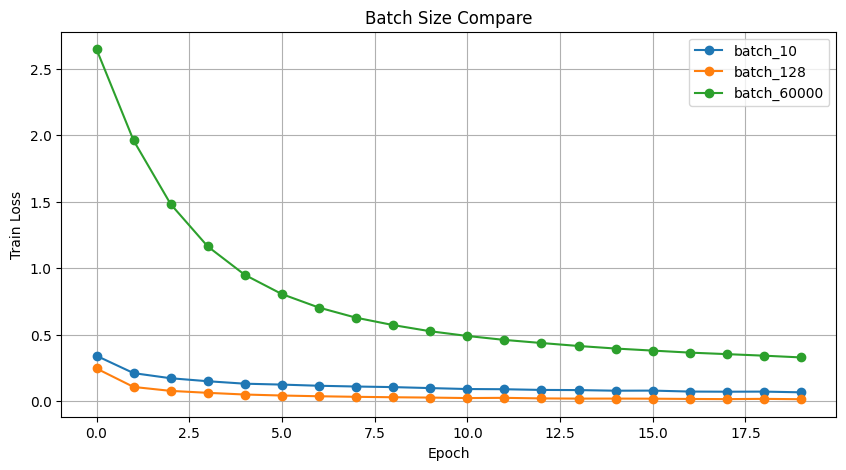


######################################################################
Learning Rate Compare
######################################################################
Model       : lr_100
Train Loss  : 13.3510
Test Loss   : 13.3918
Accuracy    : 9.58%
Total Params: 537,354
Time        : 221.26s
Model       : lr_0.1
Train Loss  : 0.0975
Test Loss   : 0.0961
Accuracy    : 97.89%
Total Params: 537,354
Time        : 213.79s
Model       : lr_0.001
Train Loss  : 0.0149
Test Loss   : 0.0537
Accuracy    : 98.44%
Total Params: 537,354
Time        : 203.42s
Model       : lr_0.00001
Train Loss  : 0.2085
Test Loss   : 0.1600
Accuracy    : 95.31%
Total Params: 537,354
Time        : 205.01s


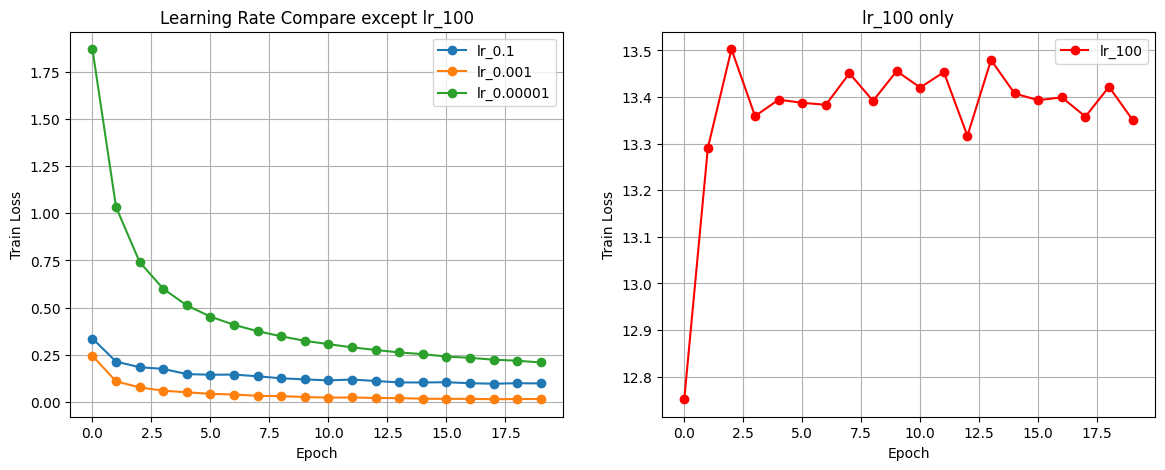


######################################################################
Dropout Compare
######################################################################
Model       : dropout_on
Train Loss  : 0.0031
Test Loss   : 0.0794
Accuracy    : 98.61%
Total Params: 537,354
Time        : 1024.15s
Model       : dropout_off
Train Loss  : 0.0005
Test Loss   : 0.0872
Accuracy    : 98.46%
Total Params: 537,354
Time        : 963.01s


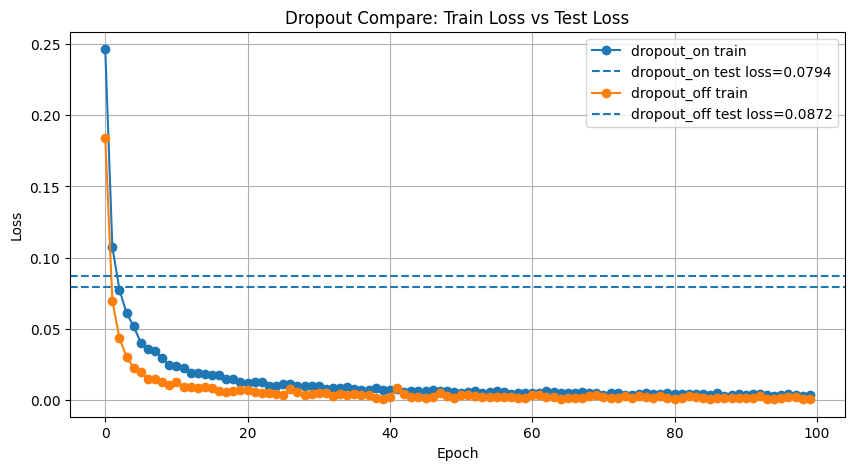


######################################################################
Optimizer Compare
######################################################################
Model       : optimizer_adam
Train Loss  : 0.0142
Test Loss   : 0.0598
Accuracy    : 98.45%
Total Params: 537,354
Time        : 216.86s
Model       : optimizer_sgd
Train Loss  : 0.3858
Test Loss   : 0.2930
Accuracy    : 92.11%
Total Params: 537,354
Time        : 163.61s


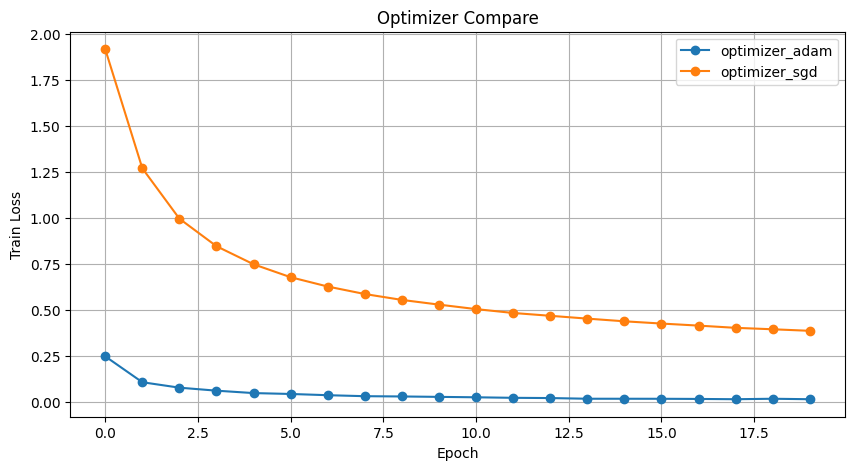


######################################################################
BatchNorm Compare
######################################################################
Model       : batchnorm_on
Train Loss  : 0.0155
Test Loss   : 0.0603
Accuracy    : 98.39%
Total Params: 537,354
Time        : 205.65s
Model       : batchnorm_off
Train Loss  : 0.0123
Test Loss   : 0.0723
Accuracy    : 98.38%
Total Params: 535,818
Time        : 181.17s


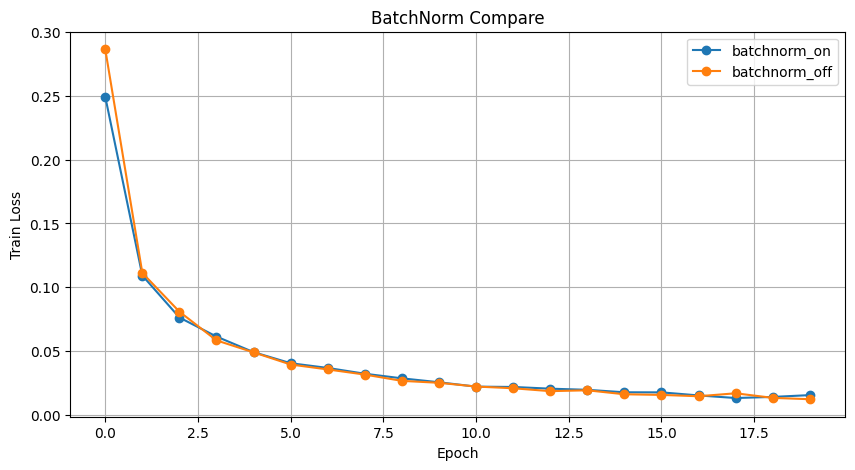

In [11]:
from training import evaluate
from losses import cross_entropy_loss
import matplotlib.pyplot as plt

groups = {
    "Batch Size Compare": [
        ("batch_10", model_batch_10, loss_batch_10, time_batch_10),
        ("batch_128", model_batch_128, loss_batch_128, time_batch_128),
        ("batch_60000", model_batch_60000, loss_batch_60000, time_batch_60000),
    ],
    "Learning Rate Compare": [
        ("lr_100", model_lr_100, loss_lr_100, time_lr_100),
        ("lr_0.1", model_lr_0_1, loss_lr_0_1, time_lr_0_1),
        ("lr_0.001", model_lr_0_001, loss_lr_0_001, time_lr_0_001),
        ("lr_0.00001", model_lr_0_00001, loss_lr_0_00001, time_lr_0_00001),
    ],
    "Dropout Compare": [
        ("dropout_on", model_dropout_on, loss_dropout_on, time_dropout_on),
        ("dropout_off", model_dropout_off, loss_dropout_off, time_dropout_off),
    ],
    "Optimizer Compare": [
        ("optimizer_adam", model_optimizer_adam, loss_optimizer_adam, time_optimizer_adam),
        ("optimizer_sgd", model_optimizer_sgd, loss_optimizer_sgd, time_optimizer_sgd),
    ],
    "BatchNorm Compare": [
        ("batchnorm_on", model_batchnorm_on, loss_batchnorm_on, time_batchnorm_on),
        ("batchnorm_off", model_batchnorm_off, loss_batchnorm_off, time_batchnorm_off),
    ],
}

results = []

for group_name, experiments in groups.items():
    print("\n" + "#" * 70)
    print(group_name)
    print("#" * 70)

    for name, model, loss_history, sec in experiments:
        train_loss = loss_history[-1]

        y_test_pred = model.predict(x_test)
        test_loss = cross_entropy_loss(y_test_pred, y_test)
        acc, n_params = evaluate(model, x_test, y_test)

        results.append((group_name, name, acc, n_params, sec, train_loss, test_loss))

        print("=" * 60)
        print(f"Model       : {name}")
        print(f"Train Loss  : {train_loss:.4f}")
        print(f"Test Loss   : {test_loss:.4f}")
        print(f"Accuracy    : {acc:.2f}%")
        print(f"Total Params: {n_params:,}")
        print(f"Time        : {sec:.2f}s")

    # Learning Rate는 lr_100 따로 분리해서 그림
    if group_name == "Learning Rate Compare":
        normal_exps = [exp for exp in experiments if exp[0] != "lr_100"]
        big_lr_exps = [exp for exp in experiments if exp[0] == "lr_100"]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for name, model, loss_history, sec in normal_exps:
            axes[0].plot(loss_history, marker="o", label=name)

        axes[0].set_xlabel("Epoch")
        axes[0].set_ylabel("Train Loss")
        axes[0].set_title("Learning Rate Compare except lr_100")
        axes[0].legend()
        axes[0].grid(True)

        for name, model, loss_history, sec in big_lr_exps:
            axes[1].plot(loss_history, marker="o", color="red", label=name)

        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Train Loss")
        axes[1].set_title("lr_100 only")
        axes[1].legend()
        axes[1].grid(True)

        plt.show()

    # Dropout은 train loss와 최종 test loss를 같이 표시
    elif group_name == "Dropout Compare":
        plt.figure(figsize=(10, 5))

        for name, model, loss_history, sec in experiments:
            y_test_pred = model.predict(x_test)
            test_loss = cross_entropy_loss(y_test_pred, y_test)

            plt.plot(loss_history, marker="o", label=f"{name} train")
            plt.axhline(test_loss, linestyle="--", label=f"{name} test loss={test_loss:.4f}")

        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Dropout Compare: Train Loss vs Test Loss")
        plt.legend()
        plt.grid(True)
        plt.show()

    # 나머지 그룹은 train loss만 그림
    else:
        plt.figure(figsize=(10, 5))

        for name, model, loss_history, sec in experiments:
            plt.plot(loss_history, marker="o", label=name)

        plt.xlabel("Epoch")
        plt.ylabel("Train Loss")
        plt.title(group_name)
        plt.legend()
        plt.grid(True)
        plt.show()

In [10]:
print("\nSummary")
print("-" * 100)
print("Group | Model | Train Loss | Test Loss | Accuracy | Time")

for group_name, name, acc, n_params, sec, train_loss, test_loss in results:
    print(
        f"{group_name} | {name} | "
        f"{train_loss:.4f} | {test_loss:.4f} | "
        f"{acc:.2f}% | {sec:.2f}s"
    )


Summary
----------------------------------------------------------------------------------------------------
Group | Model | Train Loss | Test Loss | Accuracy | Time
Batch Size Compare | batch_10 | 0.0653 | 0.0490 | 98.49% | 1790.33s
Batch Size Compare | batch_128 | 0.0135 | 0.0607 | 98.38% | 209.88s
Batch Size Compare | batch_60000 | 0.3279 | 0.2548 | 92.50% | 106.06s
Learning Rate Compare | lr_100 | 13.3510 | 13.3918 | 9.58% | 221.26s
Learning Rate Compare | lr_0.1 | 0.0975 | 0.0961 | 97.89% | 213.79s
Learning Rate Compare | lr_0.001 | 0.0149 | 0.0537 | 98.44% | 203.42s
Learning Rate Compare | lr_0.00001 | 0.2085 | 0.1600 | 95.31% | 205.01s
Dropout Compare | dropout_on | 0.0031 | 0.0794 | 98.61% | 1024.15s
Dropout Compare | dropout_off | 0.0005 | 0.0872 | 98.46% | 963.01s
Optimizer Compare | optimizer_adam | 0.0142 | 0.0598 | 98.45% | 216.86s
Optimizer Compare | optimizer_sgd | 0.3858 | 0.2930 | 92.11% | 163.61s
BatchNorm Compare | batchnorm_on | 0.0155 | 0.0603 | 98.39% | 205.65s
B

In [5]:
from network import NeuralNetwork
from optimizers import Adam, SGD
from training import train
import time
from training import evaluate

def run_train(name, model, optimizer, epochs, batch_size):
    start = time.time()

    loss_history, test_loss_history = train(
        model,
        optimizer,
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        x_test=x_test,
        y_test=y_test,
    )

    sec = time.time() - start
    test_acc, n_params = evaluate(model, x_test, y_test)

    print(
        f"{name} | epochs={epochs} | batch={batch_size} | "
        f"time={sec:.2f}s | train_loss={loss_history[-1]:.4f} | "
        f"test_loss={test_loss_history[-1]:.4f} | test_acc={test_acc:.2f}% | "
        f"params={n_params:,}"
    )

    return loss_history, test_loss_history, sec

# ============================================================
# 3. Dropout 비교
# ============================================================

model_dropout_on = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_dropout_on = Adam(lr=0.001)
loss_dropout_on, test_loss_dropout_on, time_dropout_on = run_train("dropout_on", model_dropout_on, optimizer_dropout_on, epochs=50, batch_size=128)

model_dropout_off = NeuralNetwork(use_batchnorm=True, use_dropout=False)
optimizer_dropout_off = Adam(lr=0.001)
loss_dropout_off, test_loss_dropout_off, time_dropout_off = run_train("dropout_off", model_dropout_off, optimizer_dropout_off, epochs=50, batch_size=128)


Epoch 1/50  loss: 0.2423  test_loss: 0.1057
Epoch 2/50  loss: 0.1047  test_loss: 0.0753
Epoch 3/50  loss: 0.0764  test_loss: 0.0712
Epoch 4/50  loss: 0.0604  test_loss: 0.0680
Epoch 5/50  loss: 0.0518  test_loss: 0.0588
Epoch 6/50  loss: 0.0413  test_loss: 0.0565
Epoch 7/50  loss: 0.0368  test_loss: 0.0630
Epoch 8/50  loss: 0.0306  test_loss: 0.0610
Epoch 9/50  loss: 0.0282  test_loss: 0.0631
Epoch 10/50  loss: 0.0266  test_loss: 0.0596
Epoch 11/50  loss: 0.0252  test_loss: 0.0545
Epoch 12/50  loss: 0.0206  test_loss: 0.0591
Epoch 13/50  loss: 0.0201  test_loss: 0.0604
Epoch 14/50  loss: 0.0190  test_loss: 0.0658
Epoch 15/50  loss: 0.0178  test_loss: 0.0604
Epoch 16/50  loss: 0.0151  test_loss: 0.0611
Epoch 17/50  loss: 0.0179  test_loss: 0.0617
Epoch 18/50  loss: 0.0136  test_loss: 0.0636
Epoch 19/50  loss: 0.0140  test_loss: 0.0627
Epoch 20/50  loss: 0.0125  test_loss: 0.0679
Epoch 21/50  loss: 0.0136  test_loss: 0.0676
Epoch 22/50  loss: 0.0127  test_loss: 0.0635
Epoch 23/50  loss: 

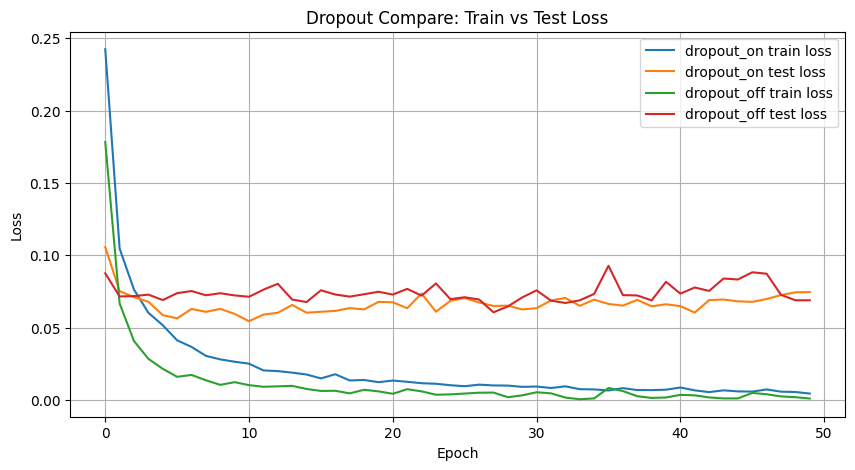

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(loss_dropout_on, label="dropout_on train loss")
plt.plot(test_loss_dropout_on, label="dropout_on test loss")

plt.plot(loss_dropout_off, label="dropout_off train loss")
plt.plot(test_loss_dropout_off, label="dropout_off test loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout Compare: Train vs Test Loss")
plt.legend()
plt.grid(True)
plt.show()

In [21]:
x_small = x_train[:200]
y_small = y_train[:200]

model = NeuralNetwork(use_batchnorm=False, use_dropout=False)
optimizer = Adam(lr=0.001)

loss_overfit, test_loss_overfit = train(
    model,
    optimizer,
    x_small,
    y_small,
    epochs=100,
    batch_size=32,
    x_test=x_test,
    y_test=y_test,
)

Epoch 1/100  loss: 1.8021  test_loss: 1.4359
Epoch 2/100  loss: 0.6917  test_loss: 0.9986
Epoch 3/100  loss: 0.3038  test_loss: 0.8449
Epoch 4/100  loss: 0.1599  test_loss: 0.8082
Epoch 5/100  loss: 0.0737  test_loss: 0.8214
Epoch 6/100  loss: 0.0314  test_loss: 0.8305
Epoch 7/100  loss: 0.0208  test_loss: 0.8036
Epoch 8/100  loss: 0.0118  test_loss: 0.8245
Epoch 9/100  loss: 0.0091  test_loss: 0.8274
Epoch 10/100  loss: 0.0069  test_loss: 0.8290
Epoch 11/100  loss: 0.0055  test_loss: 0.8375
Epoch 12/100  loss: 0.0049  test_loss: 0.8562
Epoch 13/100  loss: 0.0038  test_loss: 0.8720
Epoch 14/100  loss: 0.0036  test_loss: 0.8769
Epoch 15/100  loss: 0.0031  test_loss: 0.8766
Epoch 16/100  loss: 0.0028  test_loss: 0.8825
Epoch 17/100  loss: 0.0026  test_loss: 0.8871
Epoch 18/100  loss: 0.0024  test_loss: 0.8932
Epoch 19/100  loss: 0.0020  test_loss: 0.8975
Epoch 20/100  loss: 0.0019  test_loss: 0.9040
Epoch 21/100  loss: 0.0020  test_loss: 0.9076
Epoch 22/100  loss: 0.0017  test_loss: 0.91

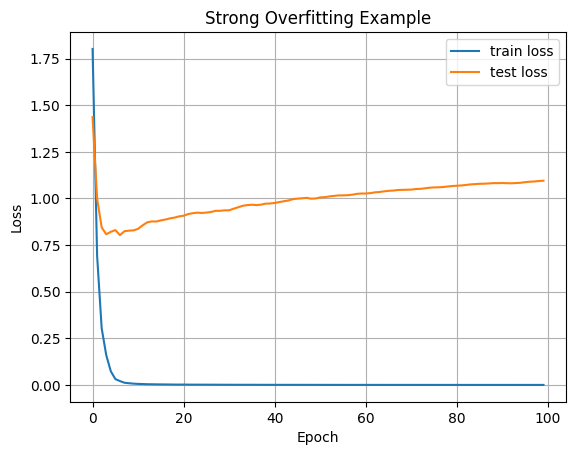

In [22]:
import matplotlib.pyplot as plt

plt.plot(loss_overfit, label="train loss")
plt.plot(test_loss_overfit, label="test loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Strong Overfitting Example")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
from network import NeuralNetwork
from optimizers import Adam
from training import train

x_small = x_train[:2000]
y_small = y_train[:2000]

dropout_experiments = [
    ("dropout_off", False, 0.0),
    ("dropout_0.1", True, 0.1),
    ("dropout_0.2", True, 0.2),
    ("dropout_0.5", True, 0.5),
    ("dropout_0.9", True, 0.9),    
]

dropout_results = {}

for name, use_dropout, dropout_ratio in dropout_experiments:
    print("=" * 60)
    print(name)

    model = NeuralNetwork(
        use_batchnorm=False,
        use_dropout=use_dropout,
        dropout_ratio=dropout_ratio,
    )
    optimizer = Adam(lr=0.001)

    train_loss, test_loss = train(
        model,
        optimizer,
        x_small,
        y_small,
        epochs=100,
        batch_size=128,
        x_test=x_test,
        y_test=y_test,
    )

    dropout_results[name] = {
        "model": model,
        "train_loss": train_loss,
        "test_loss": test_loss,
        "use_dropout": use_dropout,
        "dropout_ratio": dropout_ratio,
    }

dropout_off
Epoch 1/100  loss: 1.1817  test_loss: 0.5182
Epoch 2/100  loss: 0.3720  test_loss: 0.3942
Epoch 3/100  loss: 0.2287  test_loss: 0.3515
Epoch 4/100  loss: 0.1653  test_loss: 0.2998
Epoch 5/100  loss: 0.1065  test_loss: 0.3151
Epoch 6/100  loss: 0.0738  test_loss: 0.3021
Epoch 7/100  loss: 0.0510  test_loss: 0.2845
Epoch 8/100  loss: 0.0316  test_loss: 0.2814
Epoch 9/100  loss: 0.0210  test_loss: 0.2911
Epoch 10/100  loss: 0.0144  test_loss: 0.2959
Epoch 11/100  loss: 0.0103  test_loss: 0.2867
Epoch 12/100  loss: 0.0081  test_loss: 0.2936
Epoch 13/100  loss: 0.0063  test_loss: 0.2935
Epoch 14/100  loss: 0.0053  test_loss: 0.2960
Epoch 15/100  loss: 0.0044  test_loss: 0.2962
Epoch 16/100  loss: 0.0038  test_loss: 0.2985
Epoch 17/100  loss: 0.0033  test_loss: 0.3023
Epoch 18/100  loss: 0.0029  test_loss: 0.3019
Epoch 19/100  loss: 0.0025  test_loss: 0.3076
Epoch 20/100  loss: 0.0022  test_loss: 0.3065
Epoch 21/100  loss: 0.0020  test_loss: 0.3091
Epoch 22/100  loss: 0.0019  tes

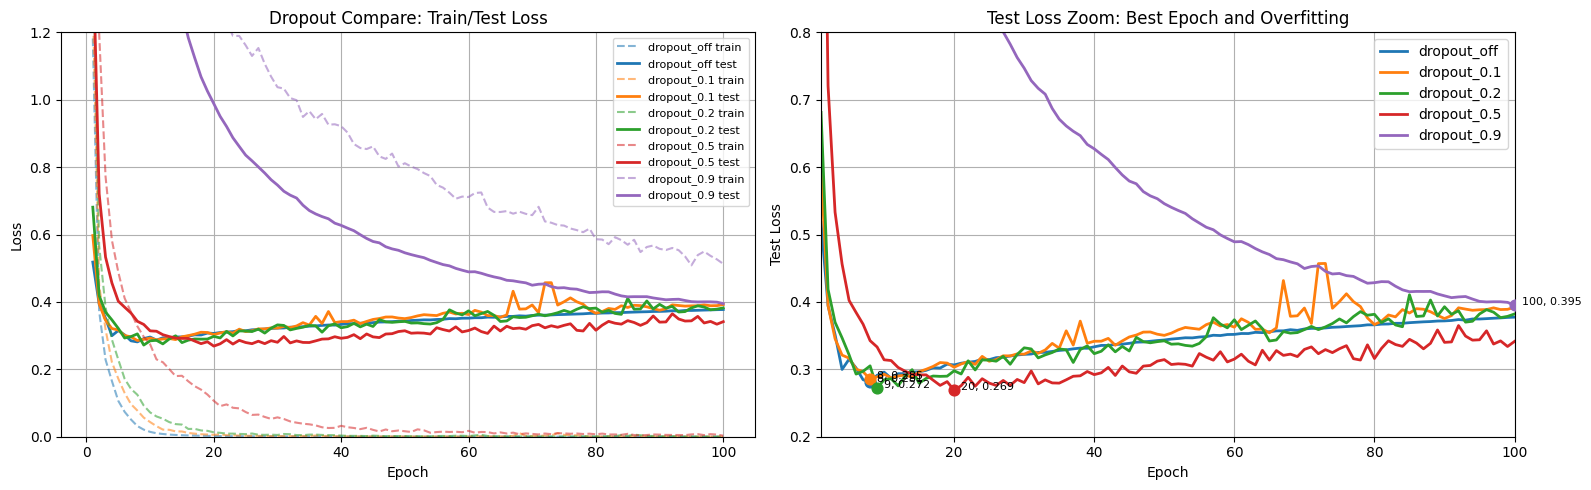

In [35]:
import matplotlib.pyplot as plt
import numpy as np

colors = {
    "dropout_off": "tab:blue",
    "dropout_0.1": "tab:orange",
    "dropout_0.2": "tab:green",
    "dropout_0.5": "tab:red",
    "dropout_0.9": "tab:purple",
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Train/Test Loss 같이 보기
ax = axes[0]

for name, result in dropout_results.items():
    train_loss = result["train_loss"]
    test_loss = result["test_loss"]
    epochs = np.arange(1, len(train_loss) + 1)

    ax.plot(epochs, train_loss, color=colors[name], linestyle="--", alpha=0.55, label=f"{name} train")
    ax.plot(epochs, test_loss, color=colors[name], linewidth=2, label=f"{name} test")

ax.set_title("Dropout Compare: Train/Test Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_ylim(0, 1.2)
ax.grid(True)
ax.legend(fontsize=8)

# 2. Test Loss 확대
ax = axes[1]

for name, result in dropout_results.items():
    test_loss = result["test_loss"]
    epochs = np.arange(1, len(test_loss) + 1)

    ax.plot(epochs, test_loss, color=colors[name], linewidth=2, label=name)

    best_idx = int(np.argmin(test_loss))
    best_epoch = best_idx + 1
    best_loss = test_loss[best_idx]

    ax.scatter(best_epoch, best_loss, color=colors[name], s=60, zorder=3)
    ax.text(best_epoch + 1, best_loss, f"{best_epoch}, {best_loss:.3f}", fontsize=8)

ax.set_title("Test Loss Zoom: Best Epoch and Overfitting")
ax.set_xlabel("Epoch")
ax.set_ylabel("Test Loss")
ax.set_xlim(1, 100)
ax.set_ylim(0.2, 0.8)
ax.grid(True)
ax.legend()

plt.tight_layout()
plt.show()

In [37]:
from training import evaluate
import numpy as np

for name, result in dropout_results.items():
    model = result["model"]
    train_loss = result["train_loss"]
    test_loss = result["test_loss"]

    best_idx = int(np.argmin(test_loss))

    test_acc, _ = evaluate(model, x_test, y_test)
    train_acc, _ = evaluate(model, x_small, y_small)

    print(
        f"{name:12s} | "
        f"best_epoch={best_idx+1:3d} | "
        f"best_test_loss={test_loss[best_idx]:.4f} | "
        f"final_test_loss={test_loss[-1]:.4f} | "
        f"final_train_loss={train_loss[-1]:.4f} | "
        f"train_acc={train_acc:.2f}% | "
        f"test_acc={test_acc:.2f}%"
    )

dropout_off  | best_epoch=  8 | best_test_loss=0.2814 | final_test_loss=0.3774 | final_train_loss=0.0001 | train_acc=100.00% | test_acc=92.40%
dropout_0.1  | best_epoch=  8 | best_test_loss=0.2854 | final_test_loss=0.3922 | final_train_loss=0.0001 | train_acc=100.00% | test_acc=92.45%
dropout_0.2  | best_epoch=  9 | best_test_loss=0.2720 | final_test_loss=0.3822 | final_train_loss=0.0003 | train_acc=100.00% | test_acc=92.68%
dropout_0.5  | best_epoch= 20 | best_test_loss=0.2689 | final_test_loss=0.3414 | final_train_loss=0.0032 | train_acc=100.00% | test_acc=92.63%
dropout_0.9  | best_epoch=100 | best_test_loss=0.3950 | final_test_loss=0.3950 | final_train_loss=0.5129 | train_acc=94.00% | test_acc=88.48%


In [9]:
from network import NeuralNetwork
from optimizers import Adam, SGD
from training import train
import time
from training import evaluate

def run_train(name, model, optimizer, epochs, batch_size):
    start = time.time()

    loss_history, test_loss_history = train(
        model,
        optimizer,
        x_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        x_test=x_test,
        y_test=y_test,
    )

    sec = time.time() - start
    test_acc, n_params = evaluate(model, x_test, y_test)

    print(
        f"{name} | epochs={epochs} | batch={batch_size} | "
        f"time={sec:.2f}s | train_loss={loss_history[-1]:.4f} | "
        f"test_loss={test_loss_history[-1]:.4f} | test_acc={test_acc:.2f}% | "
        f"params={n_params:,}"
    )

    return loss_history, test_loss_history, sec


# ============================================================
# 1. Batch Size 비교
# ============================================================

model_batch_10 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_10 = Adam(lr=0.001)
loss_batch_10, test_loss_batch_10, time_batch_10 = run_train("batch_10", model_batch_10, optimizer_batch_10, epochs=20, batch_size=10)

model_batch_128 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_128 = Adam(lr=0.001)
loss_batch_128, test_loss_batch_128, time_batch_128 = run_train("batch_128", model_batch_128, optimizer_batch_128, epochs=20, batch_size=128)

model_batch_60000 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batch_60000 = Adam(lr=0.001)
loss_batch_60000, test_loss_batch_60000, time_batch_60000 = run_train("batch_60000", model_batch_60000, optimizer_batch_60000, epochs=20, batch_size=60000)


# ============================================================
# 2. Learning Rate 비교
# ============================================================

model_lr_100 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_100 = Adam(lr=100)
loss_lr_100, test_loss_lr_100, time_lr_100 = run_train("lr_100", model_lr_100, optimizer_lr_100, epochs=20, batch_size=128)

model_lr_0_1 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_1 = Adam(lr=0.1)
loss_lr_0_1, test_loss_lr_0_1, time_lr_0_1 = run_train("lr_0.1", model_lr_0_1, optimizer_lr_0_1, epochs=20, batch_size=128)

model_lr_0_001 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_001 = Adam(lr=0.001)
loss_lr_0_001, test_loss_lr_0_001, time_lr_0_001 = run_train("lr_0.001", model_lr_0_001, optimizer_lr_0_001, epochs=20, batch_size=128)

model_lr_0_00001 = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_lr_0_00001 = Adam(lr=0.00001)
loss_lr_0_00001, test_loss_lr_0_00001, time_lr_0_00001 = run_train("lr_0.00001", model_lr_0_00001, optimizer_lr_0_00001, epochs=20, batch_size=128)


# ============================================================
# 3. Dropout 비교
# ============================================================

model_dropout_on = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_dropout_on = Adam(lr=0.001)
loss_dropout_on, test_loss_dropout_on, time_dropout_on = run_train("dropout_on", model_dropout_on, optimizer_dropout_on, epochs=100, batch_size=128)

model_dropout_off = NeuralNetwork(use_batchnorm=True, use_dropout=False)
optimizer_dropout_off = Adam(lr=0.001)
loss_dropout_off, test_loss_dropout_off, time_dropout_off = run_train("dropout_off", model_dropout_off, optimizer_dropout_off, epochs=100, batch_size=128)


# ============================================================
# 4. Optimizer 비교
# ============================================================

model_optimizer_adam = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_adam = Adam(lr=0.001)
loss_optimizer_adam, test_loss_optimizer_adam, time_optimizer_adam = run_train("optimizer_adam", model_optimizer_adam, optimizer_adam, epochs=20, batch_size=128)

model_optimizer_sgd = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_sgd = SGD(lr=0.001)
loss_optimizer_sgd, test_loss_optimizer_sgd, time_optimizer_sgd = run_train("optimizer_sgd", model_optimizer_sgd, optimizer_sgd, epochs=20, batch_size=128)


# ============================================================
# 5. BatchNorm 비교
# ============================================================

model_batchnorm_on = NeuralNetwork(use_batchnorm=True, use_dropout=True)
optimizer_batchnorm_on = Adam(lr=0.001)
loss_batchnorm_on, test_loss_batchnorm_on, time_batchnorm_on = run_train("batchnorm_on", model_batchnorm_on, optimizer_batchnorm_on, epochs=20, batch_size=128)

model_batchnorm_off = NeuralNetwork(use_batchnorm=False, use_dropout=True)
optimizer_batchnorm_off = Adam(lr=0.001)
loss_batchnorm_off, test_loss_batchnorm_off, time_batchnorm_off = run_train("batchnorm_off", model_batchnorm_off, optimizer_batchnorm_off, epochs=20, batch_size=128)

KeyboardInterrupt: 